In [27]:
import pandas as pd
import numpy as np
import torch
import torchvision
import torchmetrics
import torch.nn as nn
from pathlib import Path
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [28]:
path = Path('datasets/CTA_-_Ridership_-_Daily_Boarding_Totals_20260326.csv')
df = pd.read_csv(path, parse_dates=['service_date'], thousands=',')
df.head(3)

,service_date,day_type,bus,rail_boardings,total_rides
0,2001-01-01,U,297192,126455,423647
1,2001-01-02,W,780827,501952,1282779
2,2001-01-03,W,824923,536432,1361355


In [29]:
df.columns = ['date', 'day_type', 'bus', 'rail', 'total']
df = df.sort_values('date').set_index('date')
df = df.drop('total', axis=1)
df = df.drop_duplicates()
df.tail(3)

,day_type,bus,rail
date,,,
2026-01-29,W,604117,401847
2026-01-30,W,569408,340882
2026-01-31,A,370671,233048


<Axes: xlabel='date'>

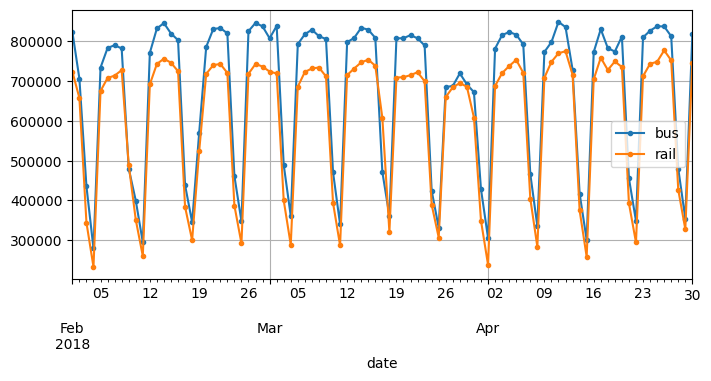

In [30]:
df.loc['2018-02':'2018-04'].plot(grid=True, marker='.', figsize=(8, 3.5))

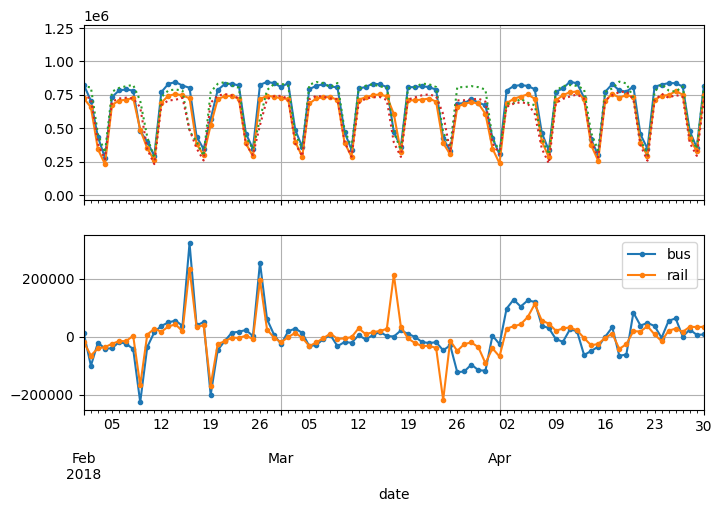

In [31]:
diff_7 = df[['bus', 'rail']].diff(7)['2018-02':'2018-04']

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
df.plot(ax=axs[0], legend=False, marker='.')
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":")
diff_7.plot(ax=axs[1], grid=True, marker='.')
plt.show()

In [32]:
diff_7.abs().mean()

bus     47615.977528
rail    37632.370787
dtype: float64

In [33]:
targets = df[['bus', 'rail']]['2018-02':'2018-04']
(diff_7/targets).abs().mean()

bus     0.075030
rail    0.071521
dtype: float64

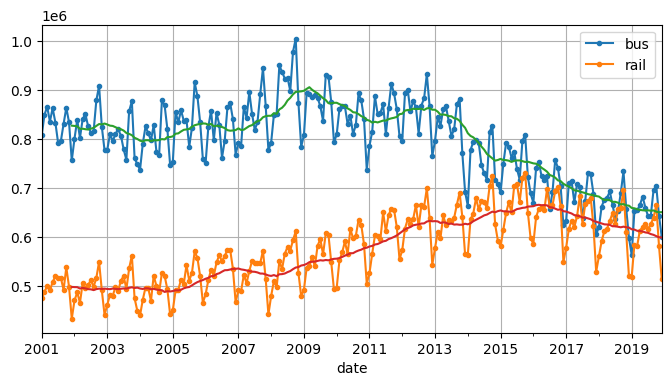

In [34]:
period = slice('2001', '2019')
df_monthly = df.select_dtypes(include='number').resample('ME').mean()
rolling_avg_12_month = df_monthly.loc[period].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(8, 4))
df_monthly[period].plot(ax=ax, marker='.')
rolling_avg_12_month.plot(ax=ax, grid=True, legend=False)
plt.show()

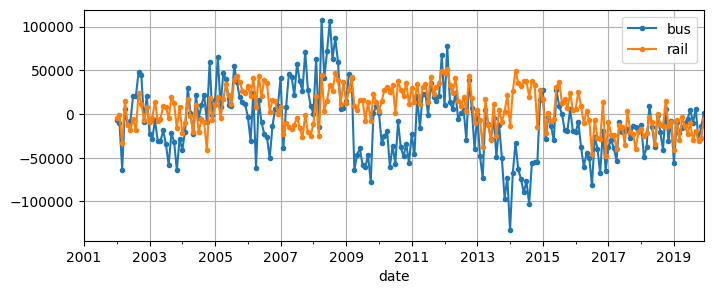

In [35]:
df_monthly.diff(12)[period].plot(grid=True, marker='.', figsize=(8, 3))
plt.show()

In [36]:
from statsmodels.tsa.arima.model import ARIMA
origin, today = '2019-01-01', '2019-05-31'
rail_series = df.loc[origin:today]['rail'].asfreq('D')

model = ARIMA(rail_series, order=(0,0,1), seasonal_order=(0,1,1,7))
model = model.fit()
y_pred = model.forecast()
print(y_pred)
print(df.loc['2019-06-01']['rail'])

2019-06-01    414935.102554
Freq: D, dtype: float64
379044


In [37]:
origin, start_date, end_date = '2019-01-01', '2019-03-01', '2019-05-31'
time_period = pd.date_range(start_date, end_date)
rail_series = df[origin:end_date]['rail'].asfreq('D')
y_preds = []
for today in time_period.shift(-1):
    model = ARIMA(rail_series[origin:today], order=(1,0,0), seasonal_order=(0,1,1,7))
    model = model.fit()
    y_pred = model.forecast().iloc[0]
    y_preds.append(y_pred)

y_preds = pd.Series(y_preds, index=time_period)
mae = (y_preds - rail_series[time_period]).abs().mean()

mae

np.float64(32040.720094289627)

In [38]:
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, series, window_length):
        self.series = series
        self.window_length = window_length
        
    def __len__(self):
        return len(self.series) - self.window_length
    
    def __getitem__(self, index):
        if index > len(self):
            raise IndexError('dataset index is out of range')
        end = index + self.window_length
        window = self.series[index:end]
        target = self.series[end]
        return window, target

In [39]:
my_series = torch.tensor([[0], [10], [20], [30], [40], [50]])
time_series = TimeSeriesDataset(my_series, window_length=3)

for window, target in time_series:
    print(f'Window: {window} Targer: {target}')

Window: tensor([[ 0],
        [10],
        [20]]) Targer: tensor([30])
Window: tensor([[10],
        [20],
        [30]]) Targer: tensor([40])
Window: tensor([[20],
        [30],
        [40]]) Targer: tensor([50])


In [40]:
from torch.utils.data import DataLoader
torch.manual_seed(0)
toy_dataloader = DataLoader(time_series, batch_size=2, shuffle=True)

for X, y in toy_dataloader:
    print(f'X: {X} y: {y}')

X: tensor([[[ 0],
         [10],
         [20]],

        [[20],
         [30],
         [40]]]) y: tensor([[30],
        [50]])
X: tensor([[[10],
         [20],
         [30]]]) y: tensor([[40]])


In [41]:
rail_train = torch.FloatTensor(df[['rail']]['2016-01':'2018-12'].values / 1e6)
rail_valid = torch.FloatTensor(df[['rail']]['2019-01':'2019-05'].values / 1e6)
rail_test  = torch.FloatTensor(df[['rail']]['2019-06':].values / 1e6)

In [42]:
train_loader = DataLoader(TimeSeriesDataset(rail_train, 56), batch_size=32, shuffle=True)
valid_loader = DataLoader(TimeSeriesDataset(rail_valid, 56), batch_size=32)
test_loader  = DataLoader(TimeSeriesDataset(rail_test, 56),  batch_size=32)

In [43]:
def train_model(model, optimizer, criterion, data_loader, n_epochs):
    model.train()
    for epoch in range(n_epochs):
        total_loss = 0
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to('cuda'), y_batch.to('cuda')
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            
            optimizer.step()
            optimizer.zero_grad()
        
        mean_loss = total_loss / len(data_loader)
        print('Epoch:', epoch, '\tloss:', mean_loss)
        
def evaluate(model, metric, data_loader):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to('cuda'), y_batch.to('cuda')
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
            
    return metric.compute()

In [44]:
model = nn.Sequential(nn.Flatten(), nn.Linear(56, 1)).to('cuda')
loss_fn = nn.HuberLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
metric = torchmetrics.MeanAbsoluteError().to('cuda')

train_model(model, optimizer, loss_fn, train_loader, 150)
evaluate(model, metric, valid_loader).item()*1e6

Epoch: 0 	loss: 0.08644634183270461
Epoch: 1 	loss: 0.013945349082915169
Epoch: 2 	loss: 0.011188089777009956
Epoch: 3 	loss: 0.009936876651464087
Epoch: 4 	loss: 0.009036032285428408
Epoch: 5 	loss: 0.008291859222068028
Epoch: 6 	loss: 0.00787906376927188
Epoch: 7 	loss: 0.007443167946555398
Epoch: 8 	loss: 0.007013937345508373
Epoch: 9 	loss: 0.006737842217482852
Epoch: 10 	loss: 0.006507126346343394
Epoch: 11 	loss: 0.006231073656994285
Epoch: 12 	loss: 0.006116543698943023
Epoch: 13 	loss: 0.005959199931980534
Epoch: 14 	loss: 0.00589040590619499
Epoch: 15 	loss: 0.0057380334685810585
Epoch: 16 	loss: 0.005632588809186762
Epoch: 17 	loss: 0.0055721728413394
Epoch: 18 	loss: 0.00548244290985167
Epoch: 19 	loss: 0.005387566271096919
Epoch: 20 	loss: 0.005342288581287545
Epoch: 21 	loss: 0.005258243799096707
Epoch: 22 	loss: 0.00526220497153135
Epoch: 23 	loss: 0.005359589319789048
Epoch: 24 	loss: 0.00519401788937323
Epoch: 25 	loss: 0.005135212820305517
Epoch: 26 	loss: 0.0050088435

45091.58432483673

In [45]:
class SimpleRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.memory_cell = nn.Sequential(nn.Linear(input_size + hidden_size, hidden_size), nn.Tanh())
        self.output = nn.Linear(hidden_size, output_size)
        
    def forward(self, X):
        batch_size, window_length, dimensionality = X.shape
        X_time_first = X.transpose(0, 1)
        H = torch.zeros(batch_size, self.hidden_size, device=X.device)
        for X_t in X_time_first:
            XH = torch.cat((X_t, H), dim=1)
            H = self.memory_cell(XH)
        return self.output(H)
    
torch.manual_seed(52)
my_model = SimpleRnnModel(1, 32)

In [46]:
class SimpleRnnModel2(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=1):
        super().__init__()
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)
        
    def forward(self, X):
        outputs, last_state = self.rnn(X)
        return self.output(outputs[:, -1])

In [47]:
df_mulvar = df[['rail', 'bus']] / 1e6
df_mulvar['next_day_type'] = df['day_type'].shift(-1)
df_mulvar = pd.get_dummies(df_mulvar, dtype=float)

mulvar_train = torch.FloatTensor(df_mulvar['2016-01':'2018-12'].values)
mulvar_valid = torch.FloatTensor(df_mulvar['2019-01':'2019-05'].values)
mulvar_test  = torch.FloatTensor(df_mulvar['2019-06':].values)

In [48]:
mulvar_train

tensor([[0.3198, 0.3033, 1.0000, 0.0000, 0.0000],
        [0.3655, 0.4489, 0.0000, 1.0000, 0.0000],
        [0.2877, 0.3405, 0.0000, 0.0000, 1.0000],
        ...,
        [0.3071, 0.3941, 0.0000, 1.0000, 0.0000],
        [0.2653, 0.3146, 0.0000, 0.0000, 1.0000],
        [0.3861, 0.4632, 0.0000, 1.0000, 0.0000]])

In [49]:
class MultivarDataloader(TimeSeriesDataset):
    def __getitem__(self, index):
        window, target = super().__getitem__(index)
        return window, target[:1]
    
multivar_dataset_train = MultivarDataloader(mulvar_train, window_length=56)
multivar_train_loader = DataLoader(multivar_dataset_train, batch_size=32, shuffle=True)

multivar_dataset_valid = MultivarDataloader(mulvar_valid, window_length=56)
multivar_valid_loader = DataLoader(multivar_dataset_valid, batch_size=32)

multivar_dataset_test = MultivarDataloader(mulvar_test, window_length=56)
multivar_test_loader = DataLoader(multivar_dataset_test, batch_size=32)

In [50]:
torch.manual_seed(52)
model = SimpleRnnModel2(input_size=5, hidden_size=32, output_size=1)
model = model.to('cuda')

In [51]:
univar_model = SimpleRnnModel2(1, 32, 1)
univar_model = univar_model.to('cuda')

optimizer = torch.optim.SGD(univar_model.parameters(), lr = 0.05, momentum=0.95, nesterov=True)
huberloss = nn.HuberLoss()
metric = torchmetrics.MeanAbsoluteError().to('cuda')

train_model(univar_model, optimizer, huberloss, train_loader, 50)
evaluate(univar_model, metric, valid_loader).item() *1e6

Epoch: 0 	loss: 0.02526355565836032
Epoch: 1 	loss: 0.012593734529659603
Epoch: 2 	loss: 0.011083584532819012
Epoch: 3 	loss: 0.009769189693598133
Epoch: 4 	loss: 0.00861769597130743
Epoch: 5 	loss: 0.0073276155233157406
Epoch: 6 	loss: 0.006412058038580598
Epoch: 7 	loss: 0.005421191326935183
Epoch: 8 	loss: 0.004877303261309862
Epoch: 9 	loss: 0.004527348622849042
Epoch: 10 	loss: 0.004148891675427105
Epoch: 11 	loss: 0.0038315991264288173
Epoch: 12 	loss: 0.0035693626039463916
Epoch: 13 	loss: 0.003232281415187048
Epoch: 14 	loss: 0.003122008012283142
Epoch: 15 	loss: 0.0028279070763594723
Epoch: 16 	loss: 0.0028506032963791354
Epoch: 17 	loss: 0.002799288651934176
Epoch: 18 	loss: 0.0028643259429372847
Epoch: 19 	loss: 0.0027449943696741352
Epoch: 20 	loss: 0.002680671170255113
Epoch: 21 	loss: 0.0026915064416684663
Epoch: 22 	loss: 0.0026975231559128697
Epoch: 23 	loss: 0.0026540364091157576
Epoch: 24 	loss: 0.0025465030568849406
Epoch: 25 	loss: 0.0026116419361311605
Epoch: 26 	l

33684.95777249336

In [52]:
univar_model.eval()
with torch.no_grad():
    X = rail_valid[:56].unsqueeze(dim=0).to('cuda')
    for step_ahead in range(14):
        y_pred_one = univar_model(X)
        X = torch.cat([X, y_pred_one.unsqueeze(dim=1)], dim=1)
    Y_pred = X[0, -14:, 0]

In [53]:
#authors way
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    device = 'cuda'
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs, patience=10, factor=0.1):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=patience, factor=factor)
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    device = 'cuda'
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        val_metric = evaluate_tm(model, valid_loader, metric).item()
        history["valid_metrics"].append(val_metric)
        scheduler.step(val_metric)
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

def fit_and_evaluate(model, train_loader, valid_loader, lr, n_epochs=50,
                     patience=20, factor=0.1):
    loss_fn = nn.HuberLoss()
    device = 'cuda'
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.95, nesterov=True)
    metric = torchmetrics.MeanAbsoluteError().to(device)
    history = train(model, optimizer, loss_fn, metric,
                    train_loader, valid_loader, n_epochs=n_epochs,
                    patience=patience, factor=factor)
    return min(history["valid_metrics"]) * 1e6

torch.manual_seed(52)
model = SimpleRnnModel2(input_size=5, hidden_size=32, output_size=1)
model = model.to('cuda')
fit_and_evaluate(model, multivar_train_loader, multivar_valid_loader, lr=0.05, n_epochs=50)

Epoch 1/50, train loss: 0.0123, train metric: 0.1074, valid metric: 0.0571
Epoch 2/50, train loss: 0.0022, train metric: 0.0462, valid metric: 0.0350
Epoch 3/50, train loss: 0.0018, train metric: 0.0399, valid metric: 0.0286
Epoch 4/50, train loss: 0.0016, train metric: 0.0379, valid metric: 0.0355
Epoch 5/50, train loss: 0.0014, train metric: 0.0364, valid metric: 0.0311
Epoch 6/50, train loss: 0.0013, train metric: 0.0347, valid metric: 0.0293
Epoch 7/50, train loss: 0.0012, train metric: 0.0336, valid metric: 0.0267
Epoch 8/50, train loss: 0.0012, train metric: 0.0334, valid metric: 0.0316
Epoch 9/50, train loss: 0.0011, train metric: 0.0324, valid metric: 0.0306
Epoch 10/50, train loss: 0.0011, train metric: 0.0321, valid metric: 0.0370
Epoch 11/50, train loss: 0.0011, train metric: 0.0324, valid metric: 0.0248
Epoch 12/50, train loss: 0.0011, train metric: 0.0326, valid metric: 0.0305
Epoch 13/50, train loss: 0.0011, train metric: 0.0320, valid metric: 0.0272
Epoch 14/50, train lo

22730.34118115902

In [54]:
class ForecastAheadDataset(TimeSeriesDataset):
    def __len__(self):
        return len(self.series) - self.window_length - 14 + 1
    
    def __getitem__(self, index):
        end = index + self.window_length 
        window = self.series[index:end] 
        target = self.series[end:end+14, 0]
        return window, target

In [55]:
ahead_train_loader = DataLoader(ForecastAheadDataset(mulvar_train, 56), batch_size=32, shuffle=True)
ahead_valid_loader = DataLoader(ForecastAheadDataset(mulvar_valid, 56), batch_size=32)
ahead_test_loader  = DataLoader(ForecastAheadDataset(mulvar_test,  56), batch_size=32)

torch.manual_seed(52)
ahead_model = SimpleRnnModel2(input_size=5, hidden_size=32, output_size=14)
ahead_model = ahead_model.to('cuda')

In [56]:
optimizer = torch.optim.SGD(ahead_model.parameters(), lr=0.05, momentum=0.95, nesterov=True)
huberloss = nn.HuberLoss()

train_model(ahead_model, optimizer, huberloss, ahead_train_loader, n_epochs=50)

Epoch: 0 	loss: 0.05275867653615547
Epoch: 1 	loss: 0.01486124267632311
Epoch: 2 	loss: 0.011422530127068361
Epoch: 3 	loss: 0.009370933738396023
Epoch: 4 	loss: 0.007898532841919046
Epoch: 5 	loss: 0.006824443145005992
Epoch: 6 	loss: 0.006004413575724218
Epoch: 7 	loss: 0.005415434356440197
Epoch: 8 	loss: 0.004974838381520275
Epoch: 9 	loss: 0.0046988970204962024
Epoch: 10 	loss: 0.0046423302159052
Epoch: 11 	loss: 0.004340678058338888
Epoch: 12 	loss: 0.0042392151133919306
Epoch: 13 	loss: 0.004323955300743833
Epoch: 14 	loss: 0.004102477807354069
Epoch: 15 	loss: 0.004043826021987832
Epoch: 16 	loss: 0.003985346443104473
Epoch: 17 	loss: 0.0039592378130747065
Epoch: 18 	loss: 0.00381264396392825
Epoch: 19 	loss: 0.0037990740260504413
Epoch: 20 	loss: 0.004000924520589637
Epoch: 21 	loss: 0.0037717182175115204
Epoch: 22 	loss: 0.0036320807906149916
Epoch: 23 	loss: 0.0036099581506498384
Epoch: 24 	loss: 0.0035708288619802756
Epoch: 25 	loss: 0.0035609554315945416
Epoch: 26 	loss: 0

In [57]:
ahead_model.eval()
with torch.no_grad():
    window = mulvar_valid[:56, :]
    X = window.unsqueeze(dim=0)
    Y_pred = ahead_model(X.to('cuda'))
Y_pred * 1e6

tensor([[725568.7500, 725325.0000, 721217.1250, 721044.8750, 401138.9688,
         320670.3125, 673519.9375, 714050.3750, 719333.8125, 730427.1875,
         709962.5000, 397939.9688, 314248.1250, 661763.8750]], device='cuda:0')

## SEQ2SEQ


In [58]:
class Seq2SeqDataset(ForecastAheadDataset):
    def __getitem__(self, index):
        end = index + self.window_length
        window = self.series[index:end]
        target_period = self.series[index+1:end+14, 0]
        target = target_period.unfold(dimension=0, size=14, step=1)
        return window, target
    
seq2seq_trainloader = DataLoader(Seq2SeqDataset(mulvar_train, 56), batch_size=32, shuffle=True)
seq2seq_validloader = DataLoader(Seq2SeqDataset(mulvar_valid, 56), batch_size=32)
seq2seq_testloader  = DataLoader(Seq2SeqDataset(mulvar_test, 56),  batch_size=32)

In [59]:
class Seq2SeqModel(SimpleRnnModel2):
    def forward(self, X):
        outputs, last_state = self.rnn(X)
        return self.output(outputs)
    
torch.manual_seed(52)
seq2seq_model = Seq2SeqModel(5, 32, 14).to('cuda')

optimizer = torch.optim.SGD(seq2seq_model.parameters(), lr =0.05, momentum=0.95, nesterov=True)
huberloss = nn.HuberLoss()
train_model(seq2seq_model, optimizer, huberloss, seq2seq_trainloader, 50)

Epoch: 0 	loss: 0.053407887843522156
Epoch: 1 	loss: 0.014731729657135227
Epoch: 2 	loss: 0.011305874834458033
Epoch: 3 	loss: 0.00911351049206022
Epoch: 4 	loss: 0.0076625726580845585
Epoch: 5 	loss: 0.0066860581070862036
Epoch: 6 	loss: 0.005940759681503881
Epoch: 7 	loss: 0.005481554025953466
Epoch: 8 	loss: 0.005080462193511652
Epoch: 9 	loss: 0.00474662793743791
Epoch: 10 	loss: 0.00458371163712758
Epoch: 11 	loss: 0.004438420764706803
Epoch: 12 	loss: 0.004426379836249081
Epoch: 13 	loss: 0.004351715451445092
Epoch: 14 	loss: 0.004219187748138652
Epoch: 15 	loss: 0.004173594759777188
Epoch: 16 	loss: 0.004099394745108756
Epoch: 17 	loss: 0.004089425409664259
Epoch: 18 	loss: 0.004018128690817816
Epoch: 19 	loss: 0.003999083585134058
Epoch: 20 	loss: 0.004056610188192942
Epoch: 21 	loss: 0.003964258400215344
Epoch: 22 	loss: 0.003927116740890073
Epoch: 23 	loss: 0.003877380129062768
Epoch: 24 	loss: 0.004016876820418419
Epoch: 25 	loss: 0.0038925437327248583
Epoch: 26 	loss: 0.003

In [60]:
seq2seq_model.eval()
with torch.no_grad():
    a_window = mulvar_valid[:56]
    X = a_window.unsqueeze(dim=0)
    Y_preds = seq2seq_model(X.to('cuda'))
    Y_pred = Y_preds[:, -1]
Y_pred * 1e6

tensor([[731402.5625, 723004.8125, 716915.8125, 717236.8750, 393465.9375,
         308955.8438, 683358.5000, 729196.2500, 722861.2500, 741419.0000,
         713907.8750, 388508.1875, 296420.6875, 683327.9375]], device='cuda:0')

In [61]:
#layer norm implemented
class SimpleRnnModelLN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.memory_cell = nn.Sequential(nn.Linear(input_size + hidden_size, hidden_size), nn.LayerNorm(), nn.Tanh())
        self.output = nn.Linear(hidden_size, output_size)
        
    def forward(self, X):
        batch_size, window_length, dimensionality = X.shape
        H = torch.zeros(batch_size, self.hidden_size, dtype=float, device=X.device)
        X_time_first = X.transpose(0, 1) 
        for X_t in X_time_first:
            XH = torch.cat((X_t, H), dim=1)
            H = self.memory_cell(XH)
        return self.output(H)

## LSTM CELL

In [62]:
class LstmLN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.memory_cell = nn.LSTM(input_size, hidden_size)
        self.output = nn.Linear(hidden_size, output_size)
        
        self.ln_h = nn.LayerNorm(hidden_size)

        
    def forward(self, X):
        batch_size, window_length, dimensionality = X.shape
        H = torch.zeros(batch_size, self.hidden_size, device=X.device)
        C = torch.zeros(batch_size, self.hidden_size, device=X.device)
        X_time_first = X.transpose(0,1)
        for X_t in X_time_first:
            H, C = self.memory_cell(X_t, (H, C))
            H = self.ln_h(H)
            
        return self.output(H)

## convolutional + recurrent

In [63]:
class DownSamplingModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.conv = nn.Conv1d(input_size, hidden_size, kernel_size=4, stride=2)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)
        
    def forward(self, X):
        Z = X.permute(0, 2, 1)
        Z = self.conv(Z)
        Z = Z.permute(0, 2, 1)
        Z = torch.relu(Z)
        Z, states_ = self.gru(Z)
        return self.output(Z)
    
class DSdataset(Seq2SeqDataset):
    def __getitem__(self, index):
        window, target = super().__getitem__(index)
        return window, target[3::2]
    
window_length = 112 #twice more because of conv layer cropping
ds_trainloader = DataLoader(DSdataset(mulvar_train, window_length=window_length), batch_size=32, shuffle=True)

### wavenet

In [64]:
class CausalConv1d(nn.Conv1d):
    def forward(self, X):
        padding = (self.kernel_size() - 1) * self.dilation[0]
        X = F.pad(X, (padding, 0))
        return super().forward(X)
    
class WaveNetModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=1):
        super().__init__()
        layers = []
        for dilation in (1, 2, 4, 8) * 2:
            conv = CausalConv1d(input_size, hidden_size, kernel_size=2, dilation=dilation)
            layers += [conv, nn.ReLU()]
            input_size = hidden_size
        self.conv_layers = nn.Sequential(*layers)
        self.output = nn.Linear(hidden_size, output_size)
        
    def forward(self, X):
        Z = X.permute(0, 2, 1)
        Z = self.conv_layers(Z)
        Z = Z.permute(0, 2, 1)
        return self.output(Z)
    
torch.manual_seed(52)
wavenet_model = WaveNetModel(input_size=5, hidden_size=32, output_size=14).to('cuda')

## #9

In [65]:
class Seq2SeqDataset2V(TimeSeriesDataset):
    def __len__(self):
        return len(self.series) - self.window_length - 14 + 1
    
    def __getitem__(self, index):
        end = index + self.window_length
        window = self.series[index:end]
        target_period = self.series[index+1:end+14, :2]
        #target_period = target_period.permute(0, 1, 3, 2)
        target = target_period.unfold(dimension=0, size=14, step=1)
        return window, target
    
seqv2_trainloader = DataLoader(Seq2SeqDataset2V(mulvar_train, 56), batch_size=32, shuffle=True)
seqv2_validloader = DataLoader(Seq2SeqDataset2V(mulvar_valid, 56), batch_size=32)
seqv2_testloader  = DataLoader(Seq2SeqDataset2V(mulvar_test, 56), batch_size=32)

seqv2_model = Seq2SeqModel(5, 32, 28).to('cuda')
optimizer = torch.optim.SGD(seqv2_model.parameters(), lr = 0.05, momentum=0.95, nesterov=True)
huberloss = nn.HuberLoss()
#train_model(seqv2_model, optimizer, huberloss, seqv2_trainloader, 50)
seqv2_model.train()
#with torch.no_grad():
for X, y in seqv2_trainloader:
        print(X.shape)
        print(y.shape, type(y))
        Y_preds = seqv2_model(X.to('cuda'))
        print(Y_preds.shape, type(Y_preds))
        y_preds = torch.zeros(32, 56, 2, 14).to('cuda')
        y_preds[:, :, 0, :] = Y_preds[:, :, :14]
        y_preds[:, :, 1, :] = Y_preds[:, :, 14:]
        print(y_preds.shape, type(y_preds))
        break

torch.Size([32, 56, 5])
torch.Size([32, 56, 2, 14]) <class 'torch.Tensor'>
torch.Size([32, 56, 28]) <class 'torch.Tensor'>
torch.Size([32, 56, 2, 14]) <class 'torch.Tensor'>


In [66]:
def train_modelv2(model, optimizer, criterion, data_loader, n_epochs):
    model.train()
    for epoch in range(n_epochs):
        total_loss = 0
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to('cuda'), y_batch.to('cuda')
            Y_preds = model(X_batch)
            
            y_preds = torch.zeros(Y_preds.shape[0], 56, 2, 14).to('cuda')
            y_preds[:, :, 0, :] = Y_preds[:, :, :14]
            y_preds[:, :, 1, :] = Y_preds[:, :, 14:]
            
            loss = criterion(y_preds, y_batch)
            total_loss += loss.item()
            loss.backward()
            
            optimizer.step()
            optimizer.zero_grad()
        
        mean_loss = total_loss / len(data_loader)
        print('Epoch:', epoch, '\tloss:', mean_loss)
        


train_modelv2(seqv2_model, optimizer, huberloss, seqv2_trainloader, 50)

Epoch: 0 	loss: 0.08197933057266654
Epoch: 1 	loss: 0.01909286802578153
Epoch: 2 	loss: 0.015105255202136257
Epoch: 3 	loss: 0.013371965650356176
Epoch: 4 	loss: 0.011572613775955908
Epoch: 5 	loss: 0.009885268398758137
Epoch: 6 	loss: 0.008659116147706905
Epoch: 7 	loss: 0.007834644974068258
Epoch: 8 	loss: 0.0073282649655911055
Epoch: 9 	loss: 0.006991636163244645
Epoch: 10 	loss: 0.006648348672597697
Epoch: 11 	loss: 0.006359765207338513
Epoch: 12 	loss: 0.006060465281321244
Epoch: 13 	loss: 0.0057445077620672455
Epoch: 14 	loss: 0.005513311575420878
Epoch: 15 	loss: 0.005303838135053714
Epoch: 16 	loss: 0.005106977878533529
Epoch: 17 	loss: 0.00490634882766189
Epoch: 18 	loss: 0.004884872980641596
Epoch: 19 	loss: 0.004641223974017935
Epoch: 20 	loss: 0.004639827201820232
Epoch: 21 	loss: 0.004504687011693463
Epoch: 22 	loss: 0.004438296235589819
Epoch: 23 	loss: 0.004452855777785633
Epoch: 24 	loss: 0.004327160503828164
Epoch: 25 	loss: 0.00427632562279927
Epoch: 26 	loss: 0.00425

In [67]:
def evaluatev2(model, metric, data_loader):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to('cuda'), y_batch.to('cuda')
            Y_preds = model(X_batch)
            
            y_preds = torch.zeros(Y_preds.shape[0], 56, 2, 14).to('cuda')
            y_preds[:, :, 0, :] = Y_preds[:, :, :14]
            y_preds[:, :, 1, :] = Y_preds[:, :, 14:]
            
            metric.update(y_preds, y_batch)
            
    return metric.compute()

metric = torchmetrics.MeanAbsoluteError().to('cuda')
evaluatev2(seqv2_model, metric, seqv2_validloader) * 1e6

tensor(52677.8828, device='cuda:0')

In [68]:
seqv2_model.eval()
with torch.no_grad():
    window = mulvar_valid[:56, :]
    X = window.unsqueeze(dim=0)
    Y_pred = seqv2_model(X.to('cuda'))
print(Y_pred * 1e6)
print(window[:, :2]*1e6)

tensor([[[564341.8750, 648736.5625, 527961.7500,  ..., 614298.5000,
          587804.4375, 496101.4688],
         [684550.9375, 619862.5625, 551982.8750,  ..., 606118.5625,
          602474.8750, 665092.4375],
         [683055.2500, 594065.5625, 550561.8750,  ..., 561701.4375,
          740443.1250, 725258.0625],
         ...,
         [297912.0625, 671780.7500, 727652.6875,  ..., 797094.8125,
          781731.4375, 430871.3125],
         [677004.2500, 741100.9375, 735158.9375,  ..., 781318.8750,
          447261.8438, 331516.0938],
         [746601.6250, 727859.3750, 743904.0000,  ..., 438976.7500,
          352748.9375, 752515.3125]]], device='cuda:0')
tensor([[245852.0000, 248879.0000],
        [573542.0000, 591006.0000],
        [627781.0000, 664442.0000],
        [628514.0000, 668812.0000],
        [348257.0000, 444434.0000],
        [260556.0156, 318623.0000],
        [662470.0000, 723023.0000],
        [701693.0000, 784085.0000],
        [685444.0000, 747949.0000],
        [6901

In [69]:
seqv2_model.eval()
with torch.no_grad():
        for X_batch, y_batch in seqv2_validloader:
            X_batch, y_batch = X_batch.to('cuda'), y_batch.to('cuda')
            Y_preds = seqv2_model(X_batch)
            
            y_preds = torch.zeros(Y_preds.shape[0], 56, 2, 14).to('cuda')
            y_preds[:, :, 0, :] = Y_preds[:, :, :14]
            y_preds[:, :, 1, :] = Y_preds[:, :, 14:]
            print(y_preds[0, 0, :, :] * 1e6)
            print()
            print(y_batch[0, 0, :, :] * 1e6)
            break

tensor([[564359.8125, 648728.6250, 527978.8750, 532878.6250, 502884.3750,
         586252.5625, 487240.9375, 627507.5000, 607582.3125, 560091.0000,
         566496.5625, 600106.0000, 550169.4375, 492177.5312],
        [646999.7500, 689638.8750, 600690.7500, 620726.1250, 595483.9375,
         536308.3125, 533057.8125, 669689.7500, 756783.0000, 562210.1250,
         624947.1875, 614325.7500, 587823.4375, 496118.3125]], device='cuda:0')

tensor([[573542.0000, 627781.0000, 628514.0000, 348257.0000, 260556.0156,
         662470.0000, 701693.0000, 685444.0000, 690162.0000, 679115.0000,
         325219.0000, 250222.0000, 705571.0000, 720095.0000],
        [591006.0000, 664442.0000, 668812.0000, 444434.0000, 318623.0000,
         723023.0000, 784085.0000, 747949.0000, 747850.0000, 763718.0000,
         382464.0000, 301855.0000, 756590.0000, 783113.0000]], device='cuda:0')


## Authors representation

In [70]:
class Seq2SeqRailBus(torch.utils.data.Dataset):
    def __init__(self, series, window_length, forecast_ahead):
        self.series = series
        self.window_length = window_length
        self.forecast_ahead = forecast_ahead
    
    def __len__(self):
        return len(self.series) - self.window_length - self.forecast_ahead + 1
    
    def __getitem__(self, index):
        if index >= len(self):
            raise IndexError('dataset index is out of range')
        end = index + self.window_length
        window = self.series[index:end]
        target_period = self.series[index+1:end+self.forecast_ahead, :2]
        target = target_period.unfold(dimension=0, size=self.forecast_ahead, step=1)
        return window, target
        

In [71]:
window_length = 56
forecast_ahead = 14

aut_train_loader = DataLoader(Seq2SeqRailBus(mulvar_train, window_length, forecast_ahead), batch_size=32, shuffle=True)
aut_valid_loader = DataLoader(Seq2SeqRailBus(mulvar_valid, window_length, forecast_ahead), batch_size=32)
aut_test_loader  = DataLoader(Seq2SeqRailBus(mulvar_test,  window_length, forecast_ahead), batch_size=32)

In [76]:
class RailBusSeqModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, output_length):
        super().__init__()
        self.memory_cell = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_length * output_size)
        self.output_length = output_length
        self.output_size = output_size
        
    def forward(self, X):
        B, L, _ = X.shape
        outputs, _last_state = self.memory_cell(X)
        y_preds = self.output(outputs)
        return y_preds.view(B, L, self.output_length, self.output_size)

In [78]:
torch.manual_seed(42)
aut_model = RailBusSeqModel(5, 32, 14, 2).to('cuda')
fit_and_evaluate(aut_model, aut_train_loader, aut_valid_loader, lr=0.05, n_epochs=50, patience=5, factor=0.5)

Epoch 1/50, train loss: 0.1253, train metric: 0.4449, valid metric: 0.1790
Epoch 2/50, train loss: 0.0237, train metric: 0.1582, valid metric: 0.1457
Epoch 3/50, train loss: 0.0180, train metric: 0.1672, valid metric: 0.1650
Epoch 4/50, train loss: 0.0172, train metric: 0.1655, valid metric: 0.1495
Epoch 5/50, train loss: 0.0168, train metric: 0.1582, valid metric: 0.1506
Epoch 6/50, train loss: 0.0166, train metric: 0.1599, valid metric: 0.1507
Epoch 7/50, train loss: 0.0163, train metric: 0.1587, valid metric: 0.1488
Epoch 8/50, train loss: 0.0163, train metric: 0.1573, valid metric: 0.1480
Epoch 9/50, train loss: 0.0160, train metric: 0.1565, valid metric: 0.1471
Epoch 10/50, train loss: 0.0158, train metric: 0.1560, valid metric: 0.1465
Epoch 11/50, train loss: 0.0157, train metric: 0.1549, valid metric: 0.1455
Epoch 12/50, train loss: 0.0157, train metric: 0.1542, valid metric: 0.1449
Epoch 13/50, train loss: 0.0155, train metric: 0.1537, valid metric: 0.1443
Epoch 14/50, train lo

112503.34978103638